In [1]:
import os
import sys

sys.path.append("..")

from ast import literal_eval
import numpy as np
from tqdm import tqdm
import pandas as pd
import glob
from shapely import wkt
from shapely.geometry import LineString


from pipelines.utils import PLAIN_DATASET_NAME, PRE_MAP_DATASET_NAME, ROOT_DIR, DATASET_NAME, PEPROCESSED_DATASET_NAME, load_road_network
from preprocessing.utils import PREPROCESS_MAP

from preprocessing.rs_mapping import create_road_mapping_df, post_processing_mapped_df, merge_preprocessed_and_fmm

from preprocessing.cell_mapping import clean_and_output_data
from preprocessing.visualize import plot_gps_traj, plot_cpath
from pipelines.utils import load_config, generate_train_test_split, generate_train_val_test_split




config = load_config(name="sf", ctype="dataset")
data_path = os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], "orig", "cabdata")



In [2]:
# read data 

all_files = glob.glob(os.path.join(data_path , "*.txt"))

data = []

for filename in all_files:
    tdf = pd.read_csv(filename, index_col=None, header=None, delimiter=" ")
    tdf["tax_id"] = filename.split("/")[-1].split(".")[0].split("_")[1]
    data.append(tdf)

df = pd.concat(data, axis=0, ignore_index=True)
df = df.rename(columns={0: "lat", 1: "long", 2: "occupied", 3: "timestamp"})

In [3]:
df.head()

,lat,long,occupied,timestamp,tax_id
0,37.75264,-122.40308,0,1213083783,acdiyito
1,37.76798,-122.40589,0,1213083711,acdiyito
2,37.76944,-122.41893,0,1213083641,acdiyito
3,37.76879,-122.41991,0,1213083590,acdiyito
4,37.76872,-122.42043,0,1213083530,acdiyito


In [4]:

import time 
# group for each taxi
rows_occ = []
rows_not_occ = []
for tax_id, g in tqdm(df.groupby("tax_id")):
    # group each occupied trajectory
    trajectories_occu = g[g['occupied'] == 1].groupby((g['occupied'] != 1).cumsum())
    trajectories_nooccu = g[g['occupied'] == 0].groupby((g['occupied'] != 0).cumsum())
    for _, t in trajectories_occu:
        if t.shape[0] < 5:
            continue
        data = t.to_numpy()
        data[:, 0], data[:, 1] = data[:, 1], data[:, 0].copy()
        coords = [tuple(coord) for coord in data[::-1, :2]]
        seq = LineString(coords)
        #seq = LineString(data[::-1, :2])
        stamps = data[::-1, 3]
        rows_occ.append((tax_id, seq, coords, stamps))
    
    for _, t in trajectories_nooccu:
        if t.shape[0] < 5:
            continue
        data = t.to_numpy()
        coords = [tuple(coord) for coord in data[::-1, :2]]
        seq = LineString(coords)
        rows_not_occ.append((tax_id, seq,coords, data[::-1, 3]))

100%|██████████| 536/536 [01:19<00:00,  6.70it/s]


In [5]:
# Create dataframes from the two lists
df_occ = pd.DataFrame(rows_occ, columns=['TAXI_ID','POLYLINE', 'coords', 'timestamps'])
df_not_occ = pd.DataFrame(rows_not_occ, columns=['TAXI_ID','POLYLINE', 'coords', 'timestamps'])

# Add the 'occupied' column
df_occ['occupied'] = 1
df_not_occ['occupied'] = 0

# Concatenate the two dataframes
df = pd.concat([df_occ, df_not_occ], ignore_index=True)#.reset_index(drop=True)

df["TRIP_ID"] = df.index

In [7]:
# save plain dataset

# Cannot save LineString to parquet, converto to string
df_plain = df.copy()
df_plain['POLYLINE'] = df_plain['POLYLINE'].apply(lambda x: wkt.dumps(x))
df_plain.to_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], PLAIN_DATASET_NAME)
)

In [2]:
# load
df_plain = pd.read_parquet(os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], PLAIN_DATASET_NAME))
df_plain['POLYLINE'] = df_plain['POLYLINE'].apply(lambda x: wkt.loads(x))

In [6]:
df_preprocessed = clean_and_output_data(df, config)

Full length. #traj=695677
Preprocessed-rm range. #traj=695613


Pandas Apply:   0%|          | 0/695613 [00:00<?, ?it/s]

Preprocessed-rm length. #traj=694779


/home/schestakov/projects/trajemb/preprocessing/../preprocessing/cell_mapping.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfraw.loc[:, 'trajlen'] = dfraw.coord_seq.swifter.apply(lambda traj: len(traj))


Pandas Apply:   0%|          | 0/694779 [00:00<?, ?it/s]

Preprocessed-output. #traj=694779
Preprocess end. @=26


In [7]:
df_preprocessed

,TRIP_ID,TAXI_ID,POLYLINE,timestamps,trajlen,coord_seq,merc_seq,occupied
0,0,abboip,"LINESTRING (-122.41527 37.7874, -122.40859 37....","[1213083415, 1213083475, 1213083535, 121308360...",6,"[(-122.41527, 37.7874), (-122.40859, 37.78833)...","[[-13627205.5217211, 4549435.943951164], [-136...",1
1,1,abboip,"LINESTRING (-122.39951 37.78881, -122.4032 37....","[1213081170, 1213081539, 1213081540, 121308154...",11,"[(-122.39951, 37.78881), (-122.4032, 37.78734)...","[[-13625451.126546199, 4549634.55714815], [-13...",1
2,2,abboip,"LINESTRING (-122.41304 37.78711, -122.41499 37...","[1213078088, 1213078127, 1213078189, 121307824...",6,"[(-122.41304, 37.78711), (-122.41499, 37.78709...","[[-13626957.279256629, 4549395.094898243], [-1...",1
3,3,abboip,"LINESTRING (-122.40998 37.80838, -122.41186 37...","[1213077504, 1213077580, 1213077634, 121307770...",10,"[(-122.40998, 37.80838), (-122.41186, 37.80509...","[[-13626616.641614804, 4552391.587082214], [-1...",1
4,4,abboip,"LINESTRING (-122.40998 37.80839, -122.41113 37...","[1213076544, 1213076658, 1213076688, 121307679...",8,"[(-122.40998, 37.80839), (-122.41113, 37.80156...","[[-13626616.641614804, 4552392.996073214], [-1...",1
...,...,...,...,...,...,...,...,...
694774,695672,uvreoipy,"LINESTRING (37.78792 -122.43339, 37.787 -122.4...","[1211049855, 1211049916, 1211049991, 121105004...",13,"[(-122.43339, 37.78792), (-122.43509, 37.787),...","[[-13629222.630894274, 4549509.190930242], [-1...",0
694775,695673,uvreoipy,"LINESTRING (37.80862 -122.4148, 37.80765 -122....","[1211048374, 1211048424, 1211048564, 121104860...",17,"[(-122.4148, 37.80862), (-122.41568, 37.80765)...","[[-13627153.201560425, 4552425.402918884], [-1...",0
694776,695674,uvreoipy,"LINESTRING (37.78509 -122.40458, 37.78351 -122...","[1211046834, 1211046899, 1211046963, 121104701...",11,"[(-122.40458, 37.78509), (-122.40731, 37.78351...","[[-13626015.516364517, 4549110.56456278], [-13...",0
694777,695675,uvreoipy,"LINESTRING (37.61535 -122.39259, 37.6155 -122....","[1211040936, 1211040999, 1211041058, 121104111...",47,"[(-122.39259, 37.61535), (-122.38853, 37.6155)...","[[-13624680.795669908, 4525229.270818511], [-1...",0


In [21]:
df_preprocessed_safe = df_preprocessed.copy()
df_preprocessed_safe['POLYLINE'] = df_preprocessed_safe['POLYLINE'].apply(lambda x: wkt.dumps(x))
df_preprocessed_safe.to_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], PEPROCESSED_DATASET_NAME)
) 

In [4]:
# load df_preprocessed dataset
df_preprocessed = pd.read_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], PEPROCESSED_DATASET_NAME)
)

In [22]:
# We need timestamps to be a string
df_preprocessed["timestamps"] = df_preprocessed["timestamps"].apply(lambda x: str(x.tolist()))
create_road_mapping_df(df_preprocessed, config["city"])

Saving preprocessed dataset to /home/schestakov/projects/trajemb/datasets/trajectory/sf/pre_map_dataset.csv


In [ ]:
# Now need to map match with fmm. See mapping.sh for how to do this.

SF looses a lot of trajectories during preprocessing.
I tried to make this better by adjusting the preprocessing for cells (trajcl), but after mapmatching (mr.csv vs mr2.csv) we obtain same amount of mapmatched trajs.
Mostly bc roadnetwork of SF is small.

In [10]:
df_fmm = pd.read_csv(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], "mr.txt"), delimiter=";"
)

In [12]:
# select rows where opath not NaN
df_fmm_nnan = df_fmm[df_fmm["opath"].notna()]

In [15]:
len(df_fmm)

406759

In [14]:
len(df_fmm_nnan)

327873

In [ ]:
df_merged = merge_preprocessed_and_fmm(df_preprocessed, df_fmm)
df = post_processing_mapped_df(df_merged)

# For classification Task we need to transform TAXI_ID to numeric values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['TAXI_ID'] = le.fit_transform(df['TAXI_ID'])
df['TAXI_ID'].max()

df.to_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], DATASET_NAME)
)

Before FMM: 406759 trips. After FMM: 327873 trips. Percentage mapped: 0.8060620662357809


327436it [00:35, 9273.28it/s] 
/home/schestakov/projects/trajemb/preprocessing/../preprocessing/rs_mapping.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["road_timestamps"] = road_stamps


In [22]:
# load
df = pd.read_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], DATASET_NAME)
)

In [ ]:
# GRID PREPROCESSING - convert lonlat to mercator
from models.utils import lonlat2meters, merc2cell2
import swifter
df['merc_seq'] = df.coord_seq.swifter.apply(lambda traj: [list(lonlat2meters(p[0], p[1])) for p in traj])
df['merc_seq'] = df['merc_seq'].apply(lambda x: [list(y) for y in x])

In [37]:
## Split data into train, val, test
train, val, test = generate_train_val_test_split(config['city'], config['seed'])

Train size: 229205, Val size: 65488, Test size: 98231


In [7]:
# Save train, val, test
train.to_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], "train", f"train_{config['seed']}.parquet")
)
val.to_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], "val", f"val_{config['seed']}.parquet")
)
test.to_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], "test", f"test_{config['seed']}.parquet")
)

array([[<AxesSubplot: title={'center': 'trajlen'}>]], dtype=object)

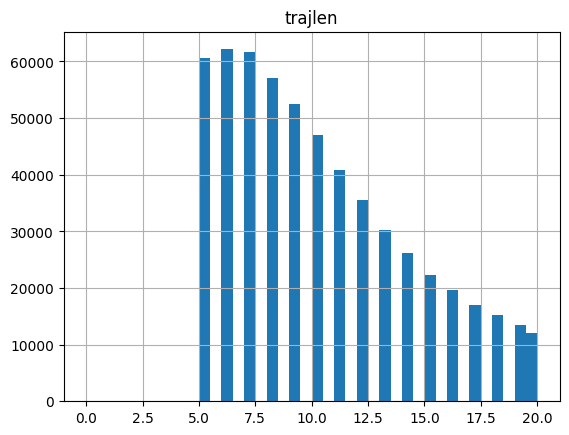

In [47]:
# print a histogram of trajectory length (column coords) of the dataset df, x should be between 0 and 200
df.hist(column='trajlen', bins=40, range=(0,20))



In [2]:
##### CALCULATE AVG. TRAVEL TIMES FOR ROAD NETWORK
from collections import defaultdict
import geopandas as gpd

# Load train data
train = pd.read_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], "train", f"train_{config['seed']}.parquet")
)
# Load val tdata
val = pd.read_parquet(
    os.path.join(ROOT_DIR, "datasets/trajectory", config["city"], "val", f"val_{config['seed']}.parquet")
)
# join both 
train = pd.concat([train, val], axis=0)

In [3]:

# Create a defaultdict to store total travel time and count for each road ID
road_stats = defaultdict(lambda: {'total_time': 0, 'count': 0})

# Iterate through all rows in the DataFrame
for _, row in tqdm(train.iterrows()):
    cpath = row['cpath']
    timestamps = row['road_timestamps']
    
    # Ensure cpath is a list of integers and timestamps is a list of Unix timestamps
    cpath = eval(cpath) if isinstance(cpath, str) else cpath
    timestamps = eval(timestamps) if isinstance(timestamps, str) else timestamps
    
    # Iterate through road segments
    for i, road_id in enumerate(cpath):
        travel_time = timestamps[i+1] - timestamps[i]
        
        # Update the road_stats dictionary
        road_stats[road_id]['total_time'] += travel_time
        road_stats[road_id]['count'] += 1

# Calculate average travel time for each road ID
average_travel_times = {road_id: stats['total_time'] / stats['count'] 
                        for road_id, stats in road_stats.items()}

# Save to Road Network
gdf_edges = gpd.read_file(
        os.path.join(ROOT_DIR, f"datasets/osm/{config['city']}/edges.shp")
    )
gdf_edges['traveltime'] = gdf_edges.index.map(average_travel_times)


294693it [00:21, 13455.58it/s]


type: 'avg_speed'

In [8]:
# ew do not get all road segements, for others calculate traveltime by length/avg_speed
gdf_edges['traveltime'] = gdf_edges.apply(lambda row: row['length'] / (50 * (1000/3600)) if row['traveltime'] == 0 or np.isnan(row['traveltime']) else row['traveltime'], axis=1)
gdf_edges.to_file(os.path.join(ROOT_DIR, f"datasets/osm/{config['city']}/edges.shp"))
